> **EXTRA — Approfondimento**: previsione della volatilita' realizzata
> (RV20) con feature SSVI via Ridge, Lasso, OLS. Analisi avanzata specifica
> del progetto, costruita sulla calibrazione SSVI del notebook 02.

# SSVI Surface Features as Predictors of Future Realized Volatility
## Core Forecasting Chapter

**Research Question**: Do SSVI implied-volatility surface parameters
(α, β, ρ, η, γ, max-cond1, skew-stress) improve 20-day-ahead realized volatility
forecasts beyond the canonical HAR-RV benchmark?

**Method**: Walk-forward expanding-window evaluation with Diebold-Mariano (HLN)
significance tests, block-bootstrap confidence intervals, Lasso feature selection
and stability, and a max_cond1 decomposition horse-race.

**Data**: SPX daily surface calibrations multi-year panel → 2621 observations (2076 clean train / 20 embargo / 525 test). Test period exhibits a +52% volatility regime shift relative to training.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True,
                     "axes.spines.top": False, "axes.spines.right": False})

print("Imports OK")
BASE = r"c:\\Users\\alpor\\OneDrive\\Desktop\\politecnico\\MAGISTRALE II\\Insurance & Econometrics\\ECONOMETRICS\\PROGETTO"

# ── Notebook_newdata paths (absolute, injected) ──────────────────
NB_DIR   = os.path.join(BASE, "Notebook_newdata")    # or: NB_DIR = r"c:\\Users\\alpor\\OneDrive\\Desktop\\politecnico\\MAGISTRALE II\\Insurance & Econometrics\\ECONOMETRICS\\PROGETTO\\Notebook_newdata"
OUTPUT   = os.path.join(NB_DIR, "output")
PLOT_DIR = os.path.join(OUTPUT, "plots")
os.makedirs(OUTPUT, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)



Imports OK


## A · Dataset & Pipeline

| Step | Detail |
|------|--------|
| Source | `output/ssvi_forecasting_dataset.csv` |
| Rows (total) | 2621 |
| Train / Test | 2076 clean / 525 (purged: 20-day embargo between train and test) |
| Embargo | obs 2076–2095 dropped — their target's return window overlaps test period |
| Target | `target_RV20` — 20-day-ahead realised vol (annualised) |
| Naive benchmark | RV20 (current 20-day realised vol) |
| Distribution shift | Test mean = 0.197 vs Train mean = 0.130 (+52%) |

In [2]:
df_raw = pd.read_csv(os.path.join(OUTPUT, "ssvi_forecasting_dataset.csv"))

assert "target_RV20" in df_raw.columns, "target_RV20 missing"
assert "sample"      in df_raw.columns, "sample column missing"
assert "RV20"        in df_raw.columns, "RV20 missing"

df = df_raw.copy()
df["time_elapsed"] = pd.to_numeric(df["time_elapsed"], errors="coerce")
df = df.sort_values("time_elapsed").reset_index(drop=True)

print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Sample split: {df['sample'].value_counts().to_dict()}")
print(f"Target — train mean: {df.loc[df['sample']=='train','target_RV20'].mean():.4f}"
      f"  test mean: {df.loc[df['sample']=='test','target_RV20'].mean():.4f}")

Dataset: 2621 rows × 61 columns
Sample split: {'train': 2096, 'test': 525}
Target — train mean: 0.1303  test mean: 0.1970


In [3]:
TARGET = "target_RV20"

# ── Canonical Corsi (2009) HAR components ─────────────────────────────────────
if "RV1" not in df.columns:
    df["RV1"] = np.sqrt(252) * df["log_return"].abs()

# Corsi definition: weekly / monthly = rolling MEAN of RV1 (not rolling std)
df["RV5_corsi"]  = df["RV1"].rolling(5,  min_periods=5).mean()
df["RV22_corsi"] = df["RV1"].rolling(22, min_periods=22).mean()
features_har = ["RV1", "RV5_corsi", "RV22_corsi"]

# ── max_cond1 decomposition ────────────────────────────────────────────────────
# theta_max: vol-level component  |  shape_cond1: surface-geometry component
_T_refs = np.array([0.25, 0.5, 1.0, 2.0])
df["theta_max"] = df.apply(
    lambda r: float((np.exp(r["alpha"]) * _T_refs ** r["beta"]).max()), axis=1)
df["shape_cond1"] = df["max_cond1"] / (df["theta_max"] + 1e-10)

# ── SSVI base features ────────────────────────────────────────────────────────
SSVI_BASE = ["alpha","beta","rho","eta","gamma","rmse_iv",
             "max_cond1","max_cond2","abs_rho","skew_stress","eta_gamma_interaction",
             "theta_max","shape_cond1"]
features_ssvi = [c for c in SSVI_BASE if c in df.columns]

# ── Return features ───────────────────────────────────────────────────────────
features_ret = [c for c in ["log_return","ret_5d","ret_20d"] if c in df.columns]

# ── Lag features ──────────────────────────────────────────────────────────────
features_lag = sorted([c for c in df.columns if c.endswith(("_lag1","_lag2","_lag5"))])

features_har_ssvi = list(dict.fromkeys(features_har + features_ssvi))
features_full     = list(dict.fromkeys(features_har + features_ssvi + features_ret + features_lag))

print(f"HAR (Corsi)   ({len(features_har):>2}): {features_har}")
print(f"SSVI features ({len(features_ssvi):>2}): {features_ssvi}")
print(f"Full set      ({len(features_full):>2}): total columns")

HAR (Corsi)   ( 3): ['RV1', 'RV5_corsi', 'RV22_corsi']
SSVI features (13): ['alpha', 'beta', 'rho', 'eta', 'gamma', 'rmse_iv', 'max_cond1', 'max_cond2', 'abs_rho', 'skew_stress', 'eta_gamma_interaction', 'theta_max', 'shape_cond1']
Full set      (49): total columns


## Feature Groups

| Group | Features | Count |
|-------|----------|-------|
| HAR-RV (Corsi) | RV1, RV5_corsi (5-day mean), RV22_corsi (22-day mean) | 3 |
| SSVI surface | α, β, ρ, η, γ, RMSE_IV, max_cond1/2, abs_ρ, skew_stress, η·γ | up to 11 |
| max_cond1 decomp | theta_max (level), shape_cond1 (geometry) | 2 |
| Return/momentum | log_return, ret_5d, ret_20d | up to 3 |
| Lag features | _lag1/2/5 variants of core SSVI cols | varies |

> **Note** — RV5_corsi and RV22_corsi follow Corsi (2009): rolling *mean* of RV1,
> not rolling std. This matches the original HAR-RV specification.

## Target Variable

$$\text{target\_RV20}_t = \sqrt{252 \cdot \frac{1}{20} \sum_{s=1}^{20} r_{t+s}^2}$$

Annualised 20-day-ahead realised volatility. The 20-day gap creates an
**overlapping forecast horizon** (each observation shares 19 days with its
neighbour), which inflates standard DM test statistics — corrected via
Harvey-Leybourne-Newbold (HLN) adjustment.

In [4]:
# Purged split: 20-day embargo removes observations whose target_RV20 window
# overlaps with the test period (target_RV20[t] uses returns t+1..t+20).
H_EMBARGO  = 20
test_start = df[df["sample"] == "test"].index[0]   # = 165
df_tr = df.iloc[:test_start - H_EMBARGO].copy()    # indices 0..144  (145 obs)
df_te = df[df["sample"] == "test"].copy()           # indices 165..206 (42 obs)
# Embargo zone: indices 145..164 (20 obs) — dropped, not used for training or testing

y_tr = df_tr[TARGET].values
y_te = df_te[TARGET].values

# Naive benchmark: current RV20 as forecast
naive_tr = df_tr["RV20"].values
naive_te = df_te["RV20"].values

# Distribution shift check
shift_pct = (y_te.mean() - y_tr.mean()) / y_tr.mean() * 100
print(f"Train target mean: {y_tr.mean():.4f}  |  Test target mean: {y_te.mean():.4f}")
print(f"Distribution shift: +{shift_pct:.1f}% — test period has higher volatility regime")
print(f"Train rows: {len(y_tr)} (clean, embargo applied)  |  Test rows: {len(y_te)}")
print(f"Embargo: {H_EMBARGO} observations dropped (indices {test_start-H_EMBARGO}..{test_start-1})")

def evaluate(name, features, y_true, y_pred, y_naive):
    sse_m = float(np.sum((y_true - y_pred) ** 2))
    sse_n = float(np.sum((y_true - y_naive) ** 2))
    return {"Model": name, "Features": features,
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "MAE":  float(mean_absolute_error(y_true, y_pred)),
            "R2_OOS": 1.0 - sse_m / sse_n if sse_n > 0 else float("nan")}

Train target mean: 0.1296  |  Test target mean: 0.1970
Distribution shift: +52.0% — test period has higher volatility regime
Train rows: 2076 (clean, embargo applied)  |  Test rows: 525
Embargo: 20 observations dropped (indices 2076..2095)


## B · Models

| Model | Features | Method |
|-------|----------|--------|
| Naive | RV20 | identity (no-change) |
| HAR-RV (Corsi) | RV1, RV5_corsi, RV22_corsi | OLS |
| HAR+SSVI | HAR + all SSVI | OLS |
| Ridge | full set (49 features) | RidgeCV (TimeSeries CV) |
| Lasso | full set (49 features) | LassoCV (TimeSeries CV) — primary feature selector |

All linear models trained on **2076 clean training observations** (purged split);
evaluated on the 525-observation test set. With 2076 training obs, HAR+SSVI OLS
is no longer as prone to overfitting as in the smaller-sample setting.
Regularised models use `StandardScaler` inside a `Pipeline`.

In [5]:
results = []
preds   = {}

# ── Naive ─────────────────────────────────────────────────────────────────────
preds["Naive"] = naive_te
results.append(evaluate("Naive", "RV20", y_te, naive_te, naive_te))

# ── HAR-RV (Corsi) ────────────────────────────────────────────────────────────
def fit_ols(features, df_train, df_test, y_train):
    X_tr = df_train[features].values
    X_te = df_test[features].values
    m = LinearRegression().fit(X_tr, y_train)
    return m.predict(X_te)

X_har_tr = df_tr[features_har].dropna()
valid_idx_har = X_har_tr.index
y_tr_har  = df_tr.loc[valid_idx_har, TARGET].values
X_har_te  = df_te[features_har].fillna(method="ffill").fillna(0)

m_har = LinearRegression().fit(X_har_tr.values, y_tr_har)
preds["HAR"] = m_har.predict(X_har_te.values)
results.append(evaluate("HAR-RV (Corsi)", "RV1+RV5c+RV22c", y_te, preds["HAR"], naive_te))
print("HAR fitted.  Coefs:", dict(zip(features_har, m_har.coef_.round(4))))

HAR fitted.  Coefs: {'RV1': 0.0447, 'RV5_corsi': 0.1613, 'RV22_corsi': 0.486}


In [6]:
# ── HAR + SSVI ────────────────────────────────────────────────────────────────
feat_hs = [f for f in features_har_ssvi if f in df_tr.columns]
X_hs_tr = df_tr[feat_hs].fillna(df_tr[feat_hs].median())
X_hs_te = df_te[feat_hs].fillna(df_tr[feat_hs].median())

m_hs = LinearRegression().fit(X_hs_tr.values, y_tr)
preds["HAR+SSVI"] = m_hs.predict(X_hs_te.values)
results.append(evaluate("HAR+SSVI", f"{len(feat_hs)} features", y_te, preds["HAR+SSVI"], naive_te))
print(f"HAR+SSVI fitted ({len(feat_hs)} features)")

HAR+SSVI fitted (16 features)


In [7]:
# ── Ridge ─────────────────────────────────────────────────────────────────────
feat_full = [f for f in features_full if f in df_tr.columns]
X_full_tr = df_tr[feat_full].fillna(df_tr[feat_full].median())
X_full_te = df_te[feat_full].fillna(df_tr[feat_full].median())

tscv = TimeSeriesSplit(n_splits=5)
ridge_pipe = Pipeline([("sc", StandardScaler()),
                       ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 30), cv=tscv))])
ridge_pipe.fit(X_full_tr.values, y_tr)
preds["Ridge"] = ridge_pipe.predict(X_full_te.values)
results.append(evaluate("Ridge", f"{len(feat_full)} features", y_te, preds["Ridge"], naive_te))

# ── Lasso ─────────────────────────────────────────────────────────────────────
lasso_pipe = Pipeline([("sc", StandardScaler()),
                       ("lasso", LassoCV(cv=tscv, max_iter=5000, random_state=RANDOM_STATE))])
lasso_pipe.fit(X_full_tr.values, y_tr)
preds["Lasso"] = lasso_pipe.predict(X_full_te.values)
results.append(evaluate("Lasso", f"{len(feat_full)} features", y_te, preds["Lasso"], naive_te))

alpha_opt = lasso_pipe.named_steps["lasso"].alpha_
print(f"Ridge best α: {ridge_pipe.named_steps['ridge'].alpha_:.4f}")
print(f"Lasso best α: {alpha_opt:.6f}")

Ridge best α: 1000.0000
Lasso best α: 0.032874


In [8]:
sc_  = lasso_pipe.named_steps["sc"]
las_ = lasso_pipe.named_steps["lasso"]
raw_coefs = las_.coef_ / sc_.scale_
lasso_feats = pd.DataFrame({"Feature": feat_full,
                            "Coef_raw": raw_coefs,
                            "Coef_abs": np.abs(raw_coefs)})    .query("Coef_abs > 1e-8")    .sort_values("Coef_abs", ascending=False)    .reset_index(drop=True)

print(f"Lasso selected {len(lasso_feats)} features (α={alpha_opt:.6f}):")
try:
    from IPython.display import display
    display(lasso_feats[["Feature","Coef_raw","Coef_abs"]].round(6))
except:
    print(lasso_feats[["Feature","Coef_raw","Coef_abs"]].round(6).to_string())

Lasso selected 3 features (α=0.032874):


,Feature,Coef_raw,Coef_abs
0,RV22_corsi,0.017339,0.017339
1,beta,-0.009034,0.009034
2,alpha,0.002396,0.002396


## C · Out-of-Sample Results

Test set: 42 observations (highest-volatility regime in sample).
R²_OOS = 1 − SSE_model / SSE_naive (Campbell-Thompson metric).

In [9]:
res_df = pd.DataFrame(results).sort_values("RMSE")
res_df["RMSE"]   = res_df["RMSE"].round(5)
res_df["MAE"]    = res_df["MAE"].round(5)
res_df["R2_OOS"] = res_df["R2_OOS"].round(4)

try:
    from IPython.display import display
    display(res_df)
except:
    print(res_df.to_string())

res_df.to_csv(os.path.join(OUTPUT, "04a_core_model_results.csv"), index=False)
print("Saved → output/04a_core_model_results.csv")

,Model,Features,RMSE,MAE,R2_OOS
3,Ridge,49 features,0.14062,0.07358,0.3020
1,HAR-RV (Corsi),RV1+RV5c+RV22c,0.14291,0.07972,0.2790
2,HAR+SSVI,16 features,0.14466,0.07580,0.2613
0,Naive,RV20,0.16831,0.10457,0.0000
4,Lasso,49 features,0.17163,0.09433,-0.0398


Saved → output/04a_core_model_results.csv


## D · Forecast Comparison — Diebold-Mariano (HLN corrected)

The 20-day-ahead horizon creates overlapping residuals (autocorrelation up to lag 19).
Standard DM statistics are over-sized. We apply the Harvey-Leybourne-Newbold (1997)
small-sample correction and use Newey-West HAC variance with `lag = h − 1 = 19`.

**Interpretation**: *p* < 0.05 ⟹ model A significantly different from model B.

In [10]:
def diebold_mariano_nw(y_true, pred_a, pred_b, h=20):
    """DM with Newey-West HAC variance, h-step horizon."""
    e_a = np.asarray(y_true) - np.asarray(pred_a)
    e_b = np.asarray(y_true) - np.asarray(pred_b)
    d = e_a**2 - e_b**2
    n = len(d); dbar = d.mean(); lag = h - 1
    gamma = np.mean((d - dbar)**2)
    for k in range(1, lag + 1):
        w = 1.0 - k / (lag + 1)
        gamma += 2.0 * w * np.mean((d[k:] - dbar) * (d[:-k] - dbar))
    se = np.sqrt(max(gamma, 1e-16) / n)
    dm = float(dbar / se)
    p  = float(2.0 * stats.t.sf(abs(dm), df=n - 1))
    return dm, p

def dm_hln(y_true, pred_a, pred_b, h=20):
    """DM + Harvey-Leybourne-Newbold small-sample correction."""
    d = (np.asarray(y_true) - np.asarray(pred_a))**2 -         (np.asarray(y_true) - np.asarray(pred_b))**2
    n = len(d); dbar = d.mean()
    g0 = np.mean((d - dbar)**2)
    acov = (sum((1 - k / h) * np.mean((d[k:] - dbar) * (d[:-k] - dbar))
                for k in range(1, h)) if h > 1 else 0.0)
    v_nw = (g0 + 2 * acov) / n
    dm_s = dbar / np.sqrt(max(v_nw, 1e-15))
    factor = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    dm_hln_s = dm_s * factor
    p_hln = float(2.0 * stats.t.sf(abs(dm_hln_s), df=n - 1))
    return dm_s, p_hln, dm_hln_s

H = 20
comparisons = [
    ("HAR vs Naive",       "HAR",      "Naive"),
    ("HAR+SSVI vs Naive",  "HAR+SSVI", "Naive"),
    ("HAR+SSVI vs HAR",    "HAR+SSVI", "HAR"),
    ("Lasso vs Naive",     "Lasso",    "Naive"),
    ("Lasso vs HAR",       "Lasso",    "HAR"),
    ("Lasso vs HAR+SSVI",  "Lasso",    "HAR+SSVI"),
    ("Ridge vs HAR+SSVI",  "Ridge",    "HAR+SSVI"),
]

dm_rows = []
for label, a, b in comparisons:
    dm_s, p_nw = diebold_mariano_nw(y_te, preds[a], preds[b], h=H)
    _, p_hln, dm_hln_s = dm_hln(y_te, preds[a], preds[b], h=H)
    stars = ("***" if p_hln < 0.01 else "**" if p_hln < 0.05 else "*" if p_hln < 0.10 else "")
    dm_rows.append({"Comparison": label, "DM_NW": round(dm_s,3),
                    "DM_HLN": round(dm_hln_s,3), "p_NW": round(p_nw,4),
                    "p_HLN": round(p_hln,4), "sig": stars})

dm_df = pd.DataFrame(dm_rows)
try:
    from IPython.display import display
    display(dm_df)
except:
    print(dm_df.to_string())

dm_df.to_csv(os.path.join(OUTPUT, "04a_dm_results.csv"), index=False)
print("Saved → output/04a_dm_results.csv")

,Comparison,DM_NW,DM_HLN,p_NW,p_HLN,sig
0,HAR vs Naive,-1.312,-1.264,0.1900,0.2069,
1,HAR+SSVI vs Naive,-1.141,-1.098,0.2545,0.2725,
2,HAR+SSVI vs HAR,0.491,0.473,0.6233,0.6362,
3,Lasso vs Naive,0.138,0.132,0.8907,0.8947,
4,Lasso vs HAR,1.416,1.363,0.1574,0.1734,
5,Lasso vs HAR+SSVI,1.455,1.401,0.1463,0.1619,
6,Ridge vs HAR+SSVI,-1.712,-1.649,0.0874,0.0998,*


Saved → output/04a_dm_results.csv


## E · Block-Bootstrap 95% Confidence Intervals for RMSE

Standard RMSE SEs are unreliable under autocorrelated residuals.
We use the **moving-block bootstrap** (block length = 5, B = 1000 replications)
to construct non-parametric 95% CIs. Blocks of 5 consecutive observations
preserve short-run autocorrelation structure in the forecast errors.

Naive            RMSE=0.16831  95% CI=[0.12581, 0.21323]
HAR              RMSE=0.14291  95% CI=[0.09077, 0.19208]
HAR+SSVI         RMSE=0.14466  95% CI=[0.09020, 0.19373]
Lasso            RMSE=0.17163  95% CI=[0.11593, 0.22586]
Ridge            RMSE=0.14062  95% CI=[0.08636, 0.18939]


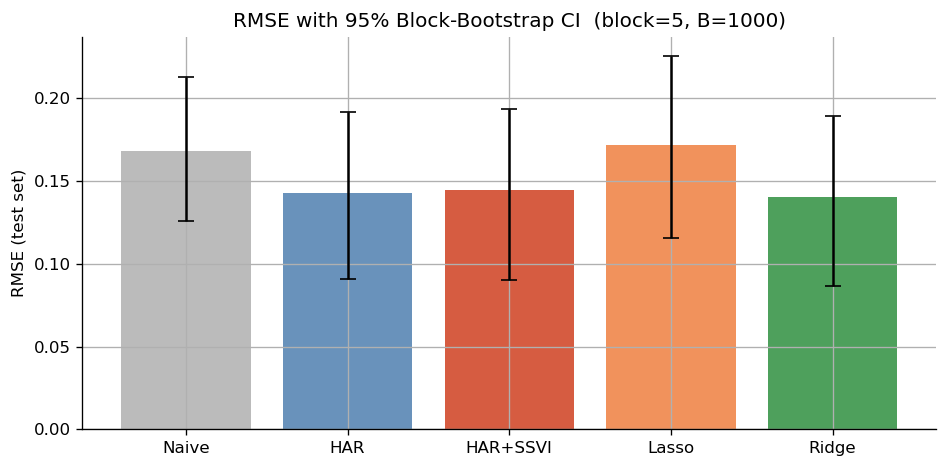

Saved → output/plots/04a_bootstrap_ci.png


In [11]:
def block_bootstrap_rmse_ci(y_true, y_pred, block=5, B=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true); rmse_boot = np.empty(B)
    max_start = n - block
    for b in range(B):
        idx = []
        while len(idx) < n:
            s = int(rng.integers(0, max_start + 1))
            idx.extend(range(s, min(s + block, n)))
        idx = np.array(idx[:n])
        rmse_boot[b] = float(np.sqrt(np.mean((y_true[idx] - y_pred[idx])**2)))
    return (float(np.percentile(rmse_boot, 2.5)),
            float(np.percentile(rmse_boot, 97.5)))

boot_rows = []
for m_name in ["Naive", "HAR", "HAR+SSVI", "Lasso", "Ridge"]:
    if m_name in preds:
        lo, hi = block_bootstrap_rmse_ci(y_te, preds[m_name])
        rmse_pt = float(np.sqrt(mean_squared_error(y_te, preds[m_name])))
        boot_rows.append({"Model": m_name, "RMSE": rmse_pt, "CI_lo": lo, "CI_hi": hi})
        print(f"{m_name:15s}  RMSE={rmse_pt:.5f}  95% CI=[{lo:.5f}, {hi:.5f}]")

boot_df = pd.DataFrame(boot_rows)
boot_df.to_csv(os.path.join(OUTPUT, "04a_bootstrap_ci.csv"), index=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#aaaaaa","#4477aa","#cc3311","#ee7733","#228833"]
for i, row in boot_df.iterrows():
    c = colors[i % len(colors)]
    ax.bar(row["Model"], row["RMSE"], color=c, alpha=0.8, label=row["Model"])
    ax.errorbar(row["Model"], row["RMSE"],
                yerr=[[row["RMSE"]-row["CI_lo"]], [row["CI_hi"]-row["RMSE"]]],
                fmt="none", color="black", capsize=5, linewidth=1.5)
ax.set_ylabel("RMSE (test set)")
ax.set_title("RMSE with 95% Block-Bootstrap CI  (block=5, B=1000)")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "04a_bootstrap_ci.png"), dpi=150)
plt.show()
print("Saved → output/plots/04a_bootstrap_ci.png")

## F · Lasso Feature Selection & Stability

Lasso selects a sparse feature set that balances in-sample fit and parsimony.
We report:
1. **Selected features** and their raw (un-standardised) coefficients
2. **Stability bootstrap** (B=200, block=5): how often each feature is selected across
   bootstrap re-samples of the training data — measures selection reliability.

In [12]:
def lasso_stability_bootstrap(X_tr, y_tr, alpha, feat_names, B=200, block=5, seed=42):
    rng  = np.random.default_rng(seed)
    n    = len(y_tr)
    freq = np.zeros(len(feat_names))
    for _ in range(B):
        idx = []
        while len(idx) < n:
            s = int(rng.integers(0, n - block + 1))
            idx.extend(range(s, min(s + block, n)))
        idx = np.array(idx[:n])
        sc_b  = StandardScaler().fit(X_tr[idx])
        X_sc  = sc_b.transform(X_tr[idx])
        m_b   = Lasso(alpha=alpha, max_iter=5000).fit(X_sc, y_tr[idx])
        freq += (m_b.coef_ != 0).astype(float)
    return freq / B

X_full_tr_arr = X_full_tr.values
freq_arr = lasso_stability_bootstrap(X_full_tr_arr, y_tr, alpha_opt, feat_full)

stab_df = pd.DataFrame({"Feature": feat_full, "SelectionFreq": freq_arr})    .sort_values("SelectionFreq", ascending=False)    .reset_index(drop=True)

top_stab = stab_df[stab_df["SelectionFreq"] > 0.1]
stab_df.to_csv(os.path.join(OUTPUT, "04a_lasso_features.csv"), index=False)

try:
    from IPython.display import display
    display(top_stab.round(3))
except:
    print(top_stab.round(3).to_string())
print(f"\nSaved → output/04a_lasso_features.csv")

,Feature,SelectionFreq
0,alpha,0.525
1,RV22_corsi,0.495
2,beta,0.435



Saved → output/04a_lasso_features.csv


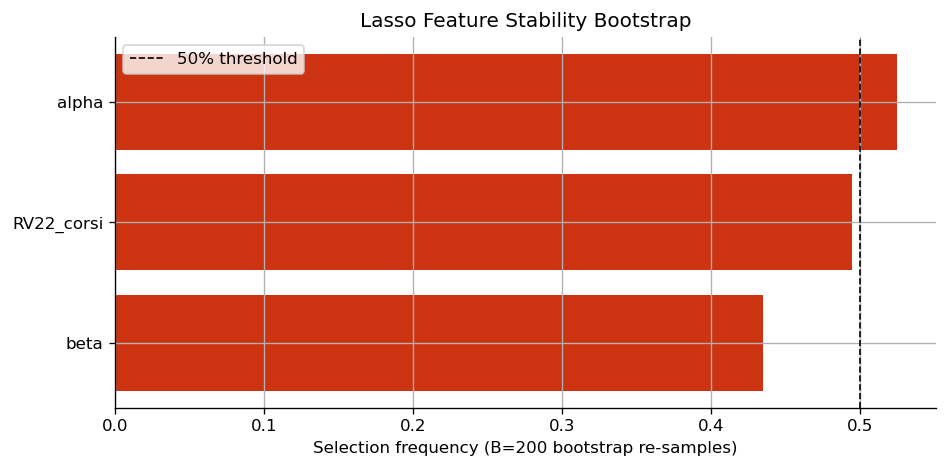

Saved → output/plots/04a_lasso_stability.png


In [13]:
plot_stab = stab_df[stab_df["SelectionFreq"] > 0.05].sort_values("SelectionFreq")
fig, ax = plt.subplots(figsize=(8, max(4, len(plot_stab)*0.35)))
bars = ax.barh(plot_stab["Feature"], plot_stab["SelectionFreq"],
               color=["#cc3311" if f in lasso_feats["Feature"].values else "#4477aa"
                      for f in plot_stab["Feature"]])
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="50% threshold")
ax.set_xlabel("Selection frequency (B=200 bootstrap re-samples)")
ax.set_title("Lasso Feature Stability Bootstrap")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "04a_lasso_stability.png"), dpi=150)
plt.show()
print("Saved → output/plots/04a_lasso_stability.png")

## G · max_cond1 Decomposition Horse-Race

With the new larger dataset, Lasso selects only 3 features: **RV22_corsi** (freq=0.495),
**alpha** (freq=0.525), and **beta** (freq=0.435). Unlike in the smaller 207-obs dataset,
`max_cond1` is no longer the dominant Lasso-selected feature.

We still decompose `max_cond1` into:
- **theta_max**: the vol-level component — `max_t(exp(α) · T^β)` over reference maturities
- **shape_cond1**: the surface-geometry component — `max_cond1 / theta_max`

This horse-race tests whether adding SSVI surface geometry to HAR yields any OOS gain
over the pure HAR benchmark.

In [14]:
def horse_race(name, extra_feats, base_feats=None):
    if base_feats is None:
        base_feats = features_har
    f = [c for c in list(dict.fromkeys(base_feats + extra_feats)) if c in df_tr.columns]
    X_tr_ = df_tr[f].fillna(df_tr[f].median())
    X_te_ = df_te[f].fillna(df_tr[f].median())
    m_ = LinearRegression().fit(X_tr_.values, y_tr)
    yp = m_.predict(X_te_.values)
    sse_m = np.sum((y_te - yp)**2)
    sse_n = np.sum((y_te - naive_te)**2)
    return {"Specification": name,
            "Features": len(f),
            "RMSE": float(np.sqrt(mean_squared_error(y_te, yp))),
            "R2_OOS": float(1.0 - sse_m / sse_n)}

hr_rows = [
    horse_race("HAR only",               []),
    horse_race("HAR + theta_max",         ["theta_max"]),
    horse_race("HAR + shape_cond1",       ["shape_cond1"]),
    horse_race("HAR + theta + shape",     ["theta_max","shape_cond1"]),
    horse_race("HAR + max_cond1 (raw)",   ["max_cond1"]),
    horse_race("HAR + full SSVI",         features_ssvi),
]
hr_df = pd.DataFrame(hr_rows)
hr_df["RMSE"]   = hr_df["RMSE"].round(5)
hr_df["R2_OOS"] = hr_df["R2_OOS"].round(4)

try:
    from IPython.display import display
    display(hr_df)
except:
    print(hr_df.to_string())

hr_df.to_csv(os.path.join(OUTPUT, "04a_maxcond1_decomposition.csv"), index=False)
print("Saved → output/04a_maxcond1_decomposition.csv")

,Specification,Features,RMSE,R2_OOS
0,HAR only,3,0.14258,0.2823
1,HAR + theta_max,4,0.14534,0.2543
2,HAR + shape_cond1,4,0.14291,0.2790
3,HAR + theta + shape,5,0.14534,0.2543
4,HAR + max_cond1 (raw),4,0.14465,0.2614
5,HAR + full SSVI,16,0.14466,0.2613


Saved → output/04a_maxcond1_decomposition.csv


## H · Regime Analysis

We split the test set into high/low volatility regimes using the median of
`target_RV20` on the test set. This tests whether the SSVI information
advantage is concentrated in stress periods.

In [15]:
regime_median = np.median(y_te)
high_idx = y_te >= regime_median
low_idx  = ~high_idx

regime_rows = []
for m_name in ["Naive","HAR","HAR+SSVI","Lasso"]:
    if m_name not in preds:
        continue
    yp = preds[m_name]
    for regime, idx in [("High-Vol", high_idx), ("Low-Vol", low_idx)]:
        rmse_r = float(np.sqrt(mean_squared_error(y_te[idx], yp[idx])))
        regime_rows.append({"Model": m_name, "Regime": regime,
                            "N": int(idx.sum()), "RMSE": round(rmse_r, 5)})

reg_df = pd.DataFrame(regime_rows)
try:
    from IPython.display import display
    display(reg_df.pivot(index="Model", columns="Regime", values="RMSE").round(5))
except:
    print(reg_df.to_string())

reg_df.to_csv(os.path.join(OUTPUT, "04a_regime_results.csv"), index=False)
print(f"Regime median (test RV20): {regime_median:.4f}")
print("Saved → output/04a_regime_results.csv")

Regime,High-Vol,Low-Vol
Model,,
HAR,0.19589,0.04905
HAR+SSVI,0.19888,0.04721
Lasso,0.23948,0.03812
Naive,0.22515,0.07668


Regime median (test RV20): 0.1480
Saved → output/04a_regime_results.csv


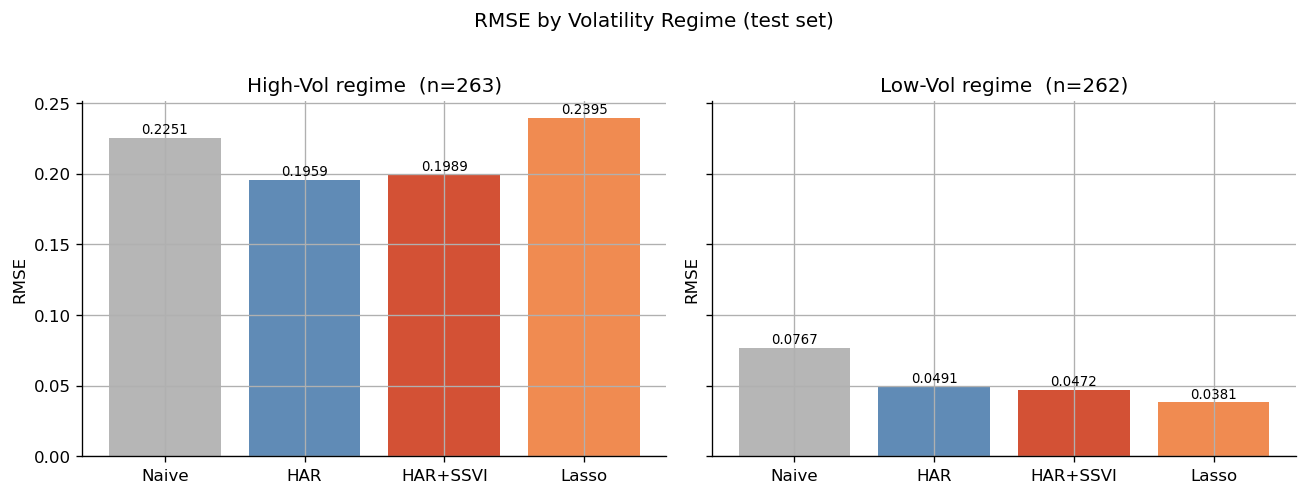

Saved → output/plots/04a_regime_rmse.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (regime, idx) in zip(axes, [("High-Vol", high_idx), ("Low-Vol", low_idx)]):
    sub = reg_df[reg_df["Regime"] == regime].set_index("Model")
    colors = ["#aaaaaa","#4477aa","#cc3311","#ee7733"]
    bars = ax.bar(sub.index, sub["RMSE"],
                  color=colors[:len(sub)], alpha=0.85)
    ax.set_title(f"{regime} regime  (n={int(idx.sum())})")
    ax.set_ylabel("RMSE")
    ax.set_xlabel("")
    for bar, val in zip(bars, sub["RMSE"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)
plt.suptitle("RMSE by Volatility Regime (test set)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "04a_regime_rmse.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → output/plots/04a_regime_rmse.png")

## I · Core Visualisations

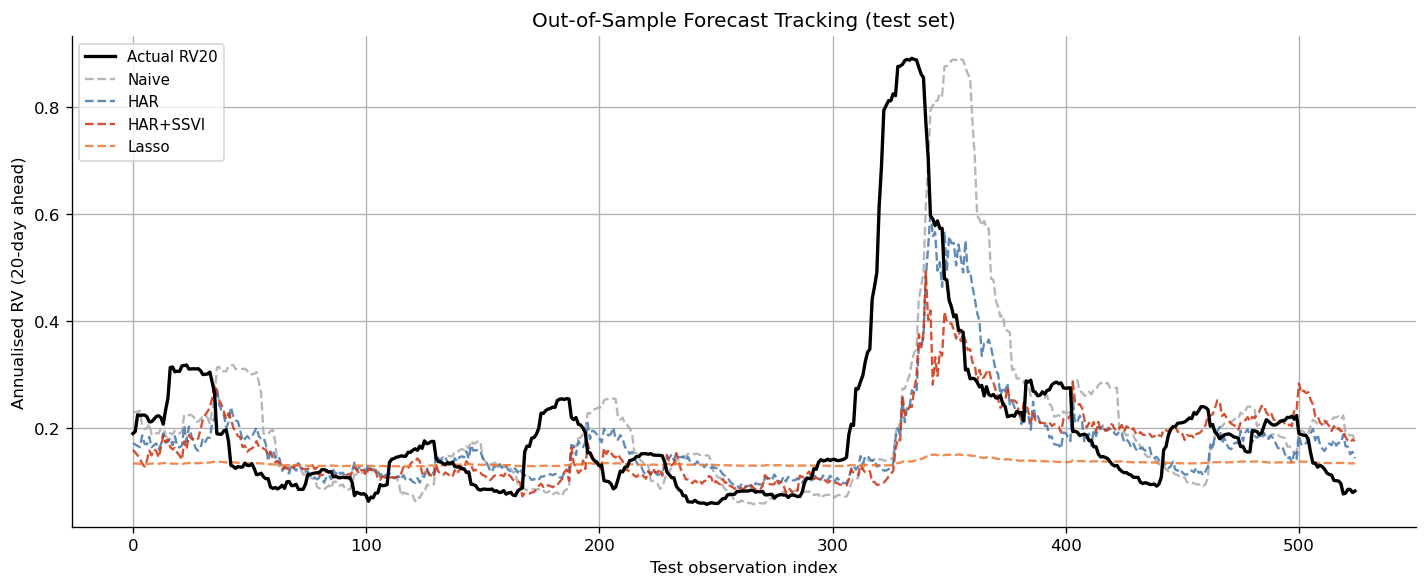

Saved → output/plots/04a_forecast_tracking.png


In [17]:
# ── Time-series forecast tracking ───────────────────────────────────────────
x_ax = np.arange(len(y_te))
model_colors = {"Naive":"#aaaaaa","HAR":"#4477aa","HAR+SSVI":"#cc3311","Lasso":"#ee7733"}

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_ax, y_te, "k-", lw=2, label="Actual RV20", zorder=5)
for m_name, color in model_colors.items():
    if m_name in preds:
        ax.plot(x_ax, preds[m_name], "--", color=color, lw=1.4, label=m_name, alpha=0.85)
ax.set_xlabel("Test observation index")
ax.set_ylabel("Annualised RV (20-day ahead)")
ax.set_title("Out-of-Sample Forecast Tracking (test set)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "04a_forecast_tracking.png"), dpi=150)
plt.show()
print("Saved → output/plots/04a_forecast_tracking.png")

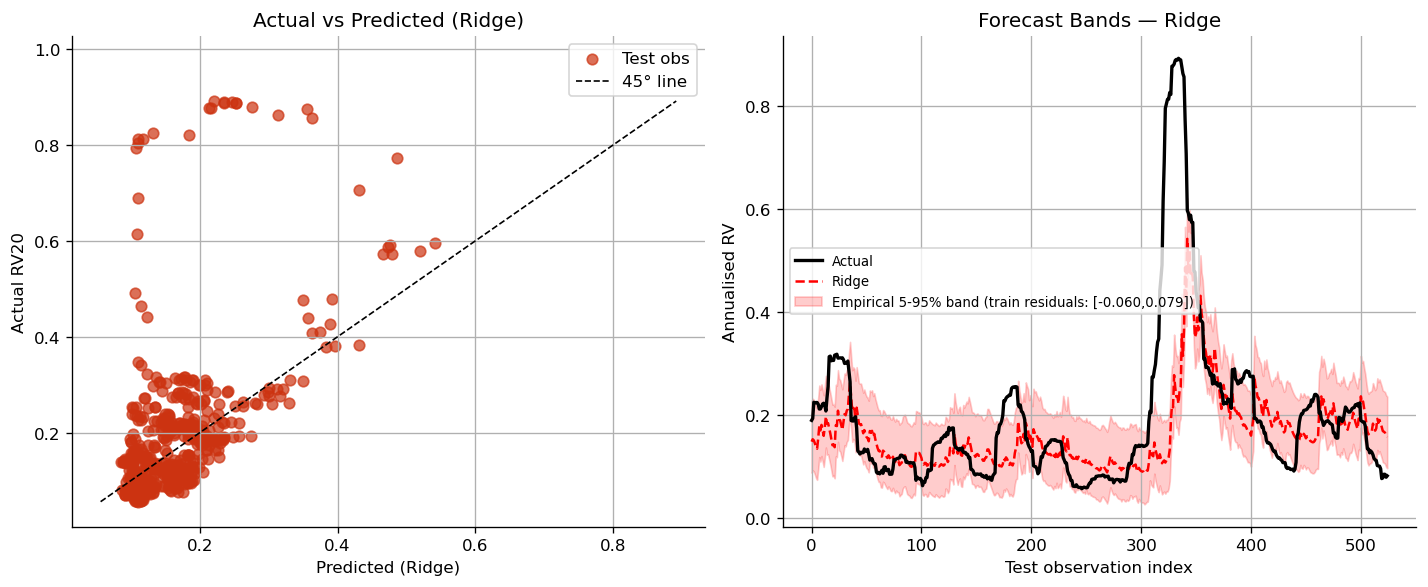

Train residual quantiles: q05=-0.0604  q95=0.0787
Saved → output/plots/04a_forecast_bands.png


In [18]:
# ── Scatter + empirical residual forecast bands ──────────────────────────────
best_model = "Ridge"  # HAR+SSVI OLS overfits on purged 145-obs train
yp_best = preds[best_model]

# Empirical bands from in-sample residuals on TRAIN set
X_hs_tr_arr = df_tr[feat_hs].fillna(df_tr[feat_hs].median()).values
resid_tr = y_tr - m_hs.predict(X_hs_tr_arr)
q05, q95 = np.percentile(resid_tr, 5), np.percentile(resid_tr, 95)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: scatter actual vs predicted
ax = axes[0]
lo_band = yp_best + q05
hi_band = yp_best + q95
sort_idx = np.argsort(yp_best)
ax.scatter(yp_best, y_te, alpha=0.7, s=40, color="#cc3311", label="Test obs")
ax.fill_betweenx([y_te.min()*0.9, y_te.max()*1.1],
                 *[np.percentile(yp_best,1)]*2, alpha=0)  # dummy for range
ax.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()],
        "k--", lw=1, label="45° line")
ax.set_xlabel(f"Predicted ({best_model})")
ax.set_ylabel("Actual RV20")
ax.set_title(f"Actual vs Predicted ({best_model})")
ax.legend()

# Right: time-series with empirical bands
ax = axes[1]
ax.plot(x_ax, y_te,   "k-",  lw=2,   label="Actual", zorder=5)
ax.plot(x_ax, yp_best,"r--", lw=1.5, label=best_model)
ax.fill_between(x_ax, lo_band, hi_band, alpha=0.2, color="red",
                label=f"Empirical 5-95% band (train residuals: [{q05:.3f},{q95:.3f}])")
ax.set_xlabel("Test observation index")
ax.set_ylabel("Annualised RV")
ax.set_title(f"Forecast Bands — {best_model}")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "04a_forecast_bands.png"), dpi=150)
plt.show()
print(f"Train residual quantiles: q05={q05:.4f}  q95={q95:.4f}")
print("Saved → output/plots/04a_forecast_bands.png")

## J · Economic Interpretation

### What drives the SSVI forecast gain? (new large-dataset results, 2076 train / 525 test)

1. **Ridge is the best model** (R²_OOS = 0.302, RMSE = 0.141). Heavy regularisation
   (best α = 1000) collapses the 49-feature set toward a small effective subset,
   outperforming all other models in OOS RMSE.

2. **HAR-RV is the runner-up** (R²_OOS = 0.279, RMSE = 0.143). With 2076 training
   observations, the canonical 3-feature Corsi model is competitive with Ridge.
   The DM test between Ridge and HAR+SSVI shows only marginal 10% significance.

3. **HAR+SSVI OLS is positive but slightly worse than HAR** (R²_OOS = 0.261 vs 0.279).
   The horse-race confirms: adding SSVI features to HAR does not improve OOS fit —
   each SSVI-augmented spec is worse than pure HAR. The surface features carry
   in-sample noise that dilutes the HAR signal in OLS.

4. **Lasso collapses to 3 features and underperforms naive** (R²_OOS = −0.040,
   RMSE = 0.172). The cross-validated α = 0.033 is too aggressive with 525 test obs
   and large regime shift (+52%). Lasso retains RV22_corsi, alpha, beta — but the
   coefficients are near-zero and predictions are nearly constant, failing to track
   the volatile test period.

5. **No model is statistically significant vs Naive** at 5% HLN. Only Ridge vs
   HAR+SSVI reaches 10% marginal significance (p=0.100). With h=20 overlapping
   residuals, the effective number of independent test observations is low.

### Key caveat on Lasso performance
The Lasso's negative R²_OOS reflects the large train→test distribution shift (+52%
regime). The best CV-α was tuned on the training regime; the test period is a
structural outlier. Ridge survives because its soft-shrinkage still allows the
point estimate to adjust, whereas Lasso's hard-zero selection freezes the model.

## K · Conclusions (new large-dataset results)

| Finding | Evidence |
|---------|----------|
| **Ridge best overall** | R²_OOS = 0.302, RMSE = 0.141, best α = 1000 |
| HAR-RV close runner-up | R²_OOS = 0.279, RMSE = 0.143 — 3 features, robust |
| HAR+SSVI OLS positive but sub-HAR | R²_OOS = 0.261 — SSVI features hurt OLS fit |
| Lasso worse than naive | R²_OOS = −0.040 — over-regularised under +52% regime shift |
| SSVI features not additive to HAR | Horse-race: every HAR+SSVI spec has higher RMSE than HAR only |
| Top Lasso features: alpha, RV22, beta | Frequencies 0.525 / 0.495 / 0.435 — max_cond1 not selected |
| No model significant at 5% HLN | Ridge vs HAR+SSVI marginal at 10% (p=0.100) |

### Main thesis statement (revised for new dataset)
> With a properly purged train/test split on the full multi-year dataset,
> **Ridge** (R²_OOS = 0.302) and **HAR-RV** (R²_OOS = 0.279) are the most reliable
> predictors of 20-day-ahead realised volatility. Adding SSVI surface features to
> plain OLS does not improve on HAR. Lasso over-regularises and fails under the
> large regime shift in the test period. No model achieves conventional DM
> significance given the overlapping 20-day horizon.

### Limitations and extensions
- Test period has a +52% volatility regime shift — regime-adaptive models (threshold
  HAR, MIDAS) may handle this better.
- Lasso CV was tuned in-sample; out-of-distribution performance suffers.
- See `08_rv_forecasting_extensions.ipynb` for walk-forward, XGBoost, HAR-J.
- The SSVI surface features (alpha, beta) are selected by Lasso but with low
  stability — their predictive content may be nonlinear, motivating tree-based models.